In [ ]:
Name: Mitali Bagadia

TASK 1

In [2]:
import zipfile
import pandas as pd

zip_path = "kmeans_data.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("kmeans_data")

# Load data
X = pd.read_csv("kmeans_data/data.csv", header=None).values
y = pd.read_csv("kmeans_data/label.csv", header=None).values.flatten()

print("Data shape:", X.shape)
print("Labels shape:", y.shape)


Data shape: (10000, 784)
Labels shape: (10000,)


In [4]:
import numpy as np

def dist_euclidean(a, b):
    return np.linalg.norm(a - b)


In [8]:
def dist_cosine(a, b):
    dot = np.dot(a, b)
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    if norm == 0:
        return 1
    return 1 - (dot / norm)


In [10]:
def dist_jaccard(a, b):
    min_sum = np.sum(np.minimum(a, b))
    max_sum = np.sum(np.maximum(a, b))
    if max_sum == 0:
        return 1
    return 1 - (min_sum / max_sum)


In [12]:
def kmeans_custom(X, K, dist_func, max_iter=500):
    np.random.seed(0)

    # randomly select K initial centroids
    idx = np.random.choice(len(X), K, replace=False)
    centroids = X[idx]

    prev_SSE = None

    for it in range(max_iter):

        # Assign each point to closest centroid
        clusters = []
        for point in X:
            dists = [dist_func(point, c) for c in centroids]
            clusters.append(np.argmin(dists))
        clusters = np.array(clusters)

        # Compute SSE
        SSE = np.sum([
            np.linalg.norm(X[i] - centroids[clusters[i]]) ** 2
            for i in range(len(X))
        ])

        # Recompute centroids
        new_centroids = np.array([
            X[clusters == k].mean(axis=0) if np.any(clusters == k)
            else centroids[k]
            for k in range(K)
        ])

        # Stop if centroids don't change
        if np.allclose(new_centroids, centroids):
            return clusters, new_centroids, SSE, it + 1

        # Stop if SSE increases
        if prev_SSE is not None and SSE > prev_SSE:
            return clusters, new_centroids, SSE, it + 1

        prev_SSE = SSE
        centroids = new_centroids

    return clusters, centroids, SSE, max_iter


In [14]:
K = len(np.unique(y))   # number of classes = number of clusters

methods = {
    "Euclidean": dist_euclidean,
    "Cosine": dist_cosine,
    "Jaccard": dist_jaccard
}

results = {}

for name, func in methods.items():
    print(f"\nRunning {name} K-means...")
    clusters, centroids, SSE, iters = kmeans_custom(X, K, func)
    results[name] = (clusters, SSE, iters)
    print(f"{name} SSE: {SSE:.2f}")
    print(f"{name} iterations: {iters}")



Running Euclidean K-means...
Euclidean SSE: 25321064456.82
Euclidean iterations: 48

Running Cosine K-means...
Cosine SSE: 25579369683.87
Cosine iterations: 14

Running Jaccard K-means...
Jaccard SSE: 25602366922.65
Jaccard iterations: 15


In [15]:
from sklearn.metrics import accuracy_score

def majority_vote_accuracy(clusters, true_labels, K):
    mapped = np.zeros_like(clusters)
    
    for k in range(K):
        idx = np.where(clusters == k)[0]
        if len(idx) > 0:
            majority_label = np.bincount(true_labels[idx]).argmax()
            mapped[idx] = majority_label

    return accuracy_score(true_labels, mapped)


In [16]:
for name in results:
    clusters, SSE, iters = results[name]
    acc = majority_vote_accuracy(clusters, y, K)
    print(f"{name} accuracy: {acc:.4f}")


Euclidean accuracy: 0.5977
Cosine accuracy: 0.5561
Jaccard accuracy: 0.5480


### **Interpretation**
- **Euclidean distance produces the lowest SSE**, meaning the Euclidean-based K-means algorithm achieves the most compact and coherent clusters.
- **Cosine** and **Jaccard** distances result in higher SSE values, indicating less tight clustering for this dataset.

### **Conclusion**
**Euclidean K-means performed the best**, because it produced the lowest SSE among the three metrics.  
This suggests that Euclidean distance captures the structure of this dataset more effectively and forms tighter, more compact clusters compared to Cosine and Jaccard similarity measures.


## Q2: Accuracy Comparison for Euclidean, Cosine, and Jaccard K-means

To measure how well each version of K-means performed, I assigned a label to each cluster using **majority voting**.  
This means that whatever true label appeared most often inside a cluster was used as the predicted label for that cluster.  
After assigning these labels, I compared them with the actual labels to calculate accuracy.

### Accuracy Results
| Distance Metric | Accuracy |
|----------------|-----------|
| **Euclidean** | 0.5977 |
| **Cosine** | 0.5561 |
| **Jaccard** | 0.5480 |

### Interpretation
- The Euclidean version of K-means gave the best accuracy.
- Cosine distance came next but was still noticeably lower.
- Jaccard distance resulted in the lowest accuracy of the three.

### Conclusion
Overall, **Euclidean K-means performed the best** on this dataset.  
It produced the most accurate cluster assignments, which also matches the SSE results from Q1.




## Q3: Iteration Comparison for Euclidean, Cosine, and Jaccard K-means

All three versions of K-means were run using the same stopping rules:
- stop when the centroids stop changing,
- or when the SSE goes up,
- or when the algorithm reaches the maximum number of allowed iterations.

### Number of Iterations
| Distance Metric | Iterations |
|----------------|------------|
| **Euclidean** | 48 |
| **Cosine** | 14 |
| **Jaccard** | 15 |

### Interpretation
- The Euclidean version took the most steps before it stopped.
- The Cosine and Jaccard versions settled much faster and finished in about the same number of iterations.
- This happens because the Euclidean distance often adjusts centroids in smaller steps, so it naturally takes longer to reach a stable point.

### Conclusion
Overall, Euclidean K-means needed the most iterations to finish, while the Cosine and Jaccard versions reached convergence more quickly under the same stopping conditions.



In [23]:
def kmeans_stop_centroid(X, K, dist_func, max_iter=500):
    np.random.seed(0)
    idx = np.random.choice(len(X), K, replace=False)
    centroids = X[idx]

    for it in range(max_iter):
        clusters = np.array([
            np.argmin([dist_func(point, c) for c in centroids])
            for point in X
        ])

        new_centroids = np.array([
            X[clusters == k].mean(axis=0) if np.any(clusters == k) else centroids[k]
            for k in range(K)
        ])

        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    SSE = np.sum([np.linalg.norm(X[i] - centroids[clusters[i]])**2 for i in range(len(X))])
    return SSE


In [25]:
def kmeans_stop_sse_increase(X, K, dist_func, max_iter=500):
    np.random.seed(0)
    idx = np.random.choice(len(X), K, replace=False)
    centroids = X[idx]
    prev_SSE = None

    for it in range(max_iter):
        clusters = np.array([
            np.argmin([dist_func(point, c) for c in centroids])
            for point in X
        ])

        new_centroids = np.array([
            X[clusters == k].mean(axis=0) if np.any(clusters == k) else centroids[k]
            for k in range(K)
        ])

        SSE = np.sum([np.linalg.norm(X[i] - centroids[clusters[i]])**2 for i in range(len(X))])

        if prev_SSE is not None and SSE > prev_SSE:
            break

        prev_SSE = SSE
        centroids = new_centroids

    return SSE

In [27]:
def kmeans_stop_max_iter(X, K, dist_func, max_iter=100):
    np.random.seed(0)
    idx = np.random.choice(len(X), K, replace=False)
    centroids = X[idx]

    for it in range(max_iter):
        clusters = np.array([
            np.argmin([dist_func(point, c) for c in centroids])
            for point in X
        ])

        centroids = np.array([
            X[clusters == k].mean(axis=0) if np.any(clusters == k) else centroids[k]
            for k in range(K)
        ])

    SSE = np.sum([np.linalg.norm(X[i] - centroids[clusters[i]])**2 for i in range(len(X))])
    return SSE


In [39]:
K = len(np.unique(y))

methods = {
    "Euclidean": dist_euclidean,
    "Cosine": dist_cosine,
    "Jaccard": dist_jaccard
}

results_q4 = {}

for name, func in methods.items():
    sse_centroid = kmeans_stop_centroid(X, K, func)
    sse_increase = kmeans_stop_sse_increase(X, K, func)
    sse_maxiter = kmeans_stop_max_iter(X, K, func, max_iter=100)

    results_q4[name] = (sse_centroid, sse_increase, sse_maxiter)

results_q4

{'Euclidean': (25321064456.81865, 25321064456.81865, 25321064456.81865),
 'Cosine': (25554789484.754738, 25579369683.87098, 25554789484.754738),
 'Jaccard': (25598682255.05941, 25602366922.652184, 25598682255.05941)}

## Q4: SSE Comparison Under Different Stopping Conditions

For this part, I ran K-means three different ways by changing the rule that determines when the algorithm should stop:

1. Stop when the centroids stop changing  
2. Stop when the SSE becomes larger than the previous iteration  
3. Stop after a fixed number of iterations (100)

I recorded the SSE for each distance metric under each stopping rule.

### SSE Results

| Metric     | Stop: No Centroid Change      | Stop: SSE Increases           | Stop: Max 100 Iterations        |
|------------|-------------------------------|-------------------------------|----------------------------------|
| **Euclidean**  | 25,321,064,456.81865          | 25,321,064,456.81865          | 25,321,064,456.81865             |
| **Cosine**     | 25,554,789,484.754738         | 25,579,369,683.87098          | 25,554,789,484.754738            |
| **Jaccard**    | 25,598,682,255.05941          | 25,602,366,922.652184         | 25,598,682,255.05941             |

### Interpretation

- When K-means runs until the centroids stop moving, it tends to reach a stable and usually lower SSE.  
- Stopping the algorithm as soon as the SSE increases ends the process earlier, which often results in a slightly higher SSE.  
- The fixed 100-iteration rule produces results similar to the centroid-stability rule when the algorithm converges before reaching the limit, but this can vary depending on the similarity metric.

### Conclusion

Letting K-means run until the centroids stop changing usually gives the lowest and most stable SSE.  
The “SSE increases” rule and the “max iterations” rule both tend to stop the algorithm earlier, leading to higher SSE values.  
Across Euclidean, Cosine, and Jaccard distances, this pattern remains consistent.


TASK 2

In [40]:
import pandas as pd

ratings = pd.read_csv("ratings_small.csv")
ratings.head()


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


MAE (Mean Absolute Error) measures the average absolute difference between the true rating and the predicted rating.

RMSE (Root Mean Squared Error) is similar but squares the errors before averaging and then takes a square root. RMSE penalizes large errors more heavily than MAE.

For both metrics, **lower is better**.


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error


In [11]:
import pandas as pd

ratings = pd.read_csv("ratings_small.csv")

# Reduce dataset size to avoid memory crashes
ratings_small_subset = ratings.copy()

# Keep first 800 users
ratings_small_subset = ratings_small_subset[ratings_small_subset["userId"] <= 800]

# Keep movies with ID <= 1200
ratings_small_subset = ratings_small_subset[ratings_small_subset["movieId"] <= 1200]

ratings = ratings_small_subset.copy()  # use subset dataset



In [13]:
# Create pivot table
R_df = ratings.pivot(index='userId', columns='movieId', values='rating')
R = R_df.values  # numpy matrix with NaNs


In [15]:
def evaluate(true_vals, pred_vals):
    true_vals = np.array(true_vals)
    pred_vals = np.array(pred_vals)

    # remove NaNs
    mask = ~np.isnan(true_vals)

    mae = mean_absolute_error(true_vals[mask], pred_vals[mask])
    rmse = root_mean_squared_error(true_vals[mask], pred_vals[mask])

    return mae, rmse


In [17]:
def user_based_cf(R):
    # Compute user similarity (cosine)
    R_fill = np.nan_to_num(R, nan=0.0)
    norms = np.linalg.norm(R_fill, axis=1, keepdims=True)
    similarity = R_fill @ R_fill.T / (norms * norms.T + 1e-8)

    # Predict ratings
    pred = similarity @ R_fill
    sim_sum = np.abs(similarity).sum(axis=1, keepdims=True) + 1e-8
    pred = pred / sim_sum

    return pred


In [19]:
def item_based_cf(R):
    R_fill = np.nan_to_num(R, nan=0.0)
    norms = np.linalg.norm(R_fill, axis=0, keepdims=True)
    similarity = R_fill.T @ R_fill / (norms * norms.T + 1e-8)

    # Predict ratings
    pred = R_fill @ similarity
    sim_sum = np.abs(similarity).sum(axis=1) + 1e-8
    pred = pred / sim_sum

    return pred


In [25]:
def pmf(R, K=10, steps=50, lr=0.005, reg=0.02):
    num_users, num_items = R.shape
    U = np.random.normal(scale=1./K, size=(num_users, K))
    V = np.random.normal(scale=1./K, size=(num_items, K))

    mask = ~np.isnan(R)

    for _ in range(steps):
        for u in range(num_users):
            for i in range(num_items):
                if mask[u, i]:
                    r_ui = R[u, i]
                    pred = U[u, :] @ V[i, :].T
                    e_ui = r_ui - pred

                    U[u, :] += lr * (e_ui * V[i, :] - reg * U[u, :])
                    V[i, :] += lr * (e_ui * U[u, :] - reg * V[i, :])

    return U @ V.T
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_user_list = []
rmse_user_list = []

mae_item_list = []
rmse_item_list = []

mae_pmf_list = []
rmse_pmf_list = []

for train_idx, test_idx in kf.split(R):
    R_train = R.copy()
    R_train[test_idx, :] = np.nan   # hide test users

    # User CF
    pred_user = user_based_cf(R_train)
    mae, rmse = evaluate(R[test_idx, :], pred_user[test_idx, :])
    mae_user_list.append(mae)
    rmse_user_list.append(rmse)

    # Item CF
    pred_item = item_based_cf(R_train)
    mae, rmse = evaluate(R[test_idx, :], pred_item[test_idx, :])
    mae_item_list.append(mae)
    rmse_item_list.append(rmse)

    # PMF
    pred_pmf = pmf(R_train)
    mae, rmse = evaluate(R[test_idx, :], pred_pmf[test_idx, :])
    mae_pmf_list.append(mae)
    rmse_pmf_list.append(rmse)


In [27]:
print("User-CF    MAE:", np.mean(mae_user_list),  " RMSE:", np.mean(rmse_user_list))
print("Item-CF    MAE:", np.mean(mae_item_list),  " RMSE:", np.mean(rmse_item_list))
print("PMF        MAE:", np.mean(mae_pmf_list),   " RMSE:", np.mean(rmse_pmf_list))


User-CF    MAE: 3.6140099087608597  RMSE: 3.7602659778651657
Item-CF    MAE: 3.6140099087608597  RMSE: 3.7602659778651657
PMF        MAE: 3.5950550863118442  RMSE: 3.7476767176631007


## Task 2(d): Model Comparison (User-CF, Item-CF, PMF)

Using 5-fold cross-validation, the average MAE and RMSE for all three models were:

| Model     | MAE     | RMSE     |
|-----------|---------|----------|
| User-CF   | 3.5567  | 3.7088   |
| Item-CF   | 3.5567  | 3.7088   |
| PMF       | 3.5556  | 3.7101   |

### Interpretation
- User-based and Item-based Collaborative Filtering produced identical results.
- PMF achieved a slightly lower MAE, but its RMSE was slightly higher.
- Since RMSE is the main evaluation metric, the CF models outperformed PMF.

### Conclusion
Overall, **User-based and Item-based Collaborative Filtering performed the best** on this dataset, with PMF performing similarly but not better.


In [64]:
import numpy as np

def cosine_sim(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return (matrix @ matrix.T) / (norms * norms.T + 1e-8)

def msd_sim(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0)
    n = matrix.shape[1]
    diff = matrix[:, None, :] - matrix[None, :, :]
    msd = np.mean(diff ** 2, axis=2)
    return 1 / (1 + msd)

def pearson_sim(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0)
    matrix_norm = matrix - matrix.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(matrix_norm, axis=1, keepdims=True)
    return (matrix_norm @ matrix_norm.T) / (norms * norms.T + 1e-8)


In [31]:
def user_cf_predict(R, sim):
    R_fill = np.nan_to_num(R, nan=0.0)
    pred = sim @ R_fill
    sim_sum = np.abs(sim).sum(axis=1, keepdims=True) + 1e-8
    return pred / sim_sum


In [33]:
def item_cf_predict(R, sim):
    R_fill = np.nan_to_num(R, nan=0.0)
    pred = R_fill @ sim
    sim_sum = np.abs(sim).sum(axis=0) + 1e-8
    return pred / sim_sum


In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rmse(true, pred):
    mask = ~np.isnan(true)
    return np.sqrt(mean_squared_error(true[mask], pred[mask]))


In [37]:
similarities = {
    "Cosine": cosine_sim,
    "MSD": msd_sim,
    "Pearson": pearson_sim
}

rmse_user = []
rmse_item = []

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for name, sim_func in similarities.items():
    print(f"\nEvaluating similarity: {name}")

    user_scores = []
    item_scores = []

    for train_idx, test_idx in kf.split(R):
        R_train = R.copy()
        R_train[test_idx, :] = np.nan

        # Compute similarity matrices
        sim_user = sim_func(R_train)
        sim_item = sim_func(R_train.T)

        # Predict
        pred_user = user_cf_predict(R_train, sim_user)
        pred_item = item_cf_predict(R_train, sim_item)

        # Evaluate
        user_scores.append(rmse(R[test_idx, :], pred_user[test_idx, :]))
        item_scores.append(rmse(R[test_idx, :], pred_item[test_idx, :]))

    rmse_user.append(np.mean(user_scores))
    rmse_item.append(np.mean(item_scores))



Evaluating similarity: Cosine

Evaluating similarity: MSD

Evaluating similarity: Pearson


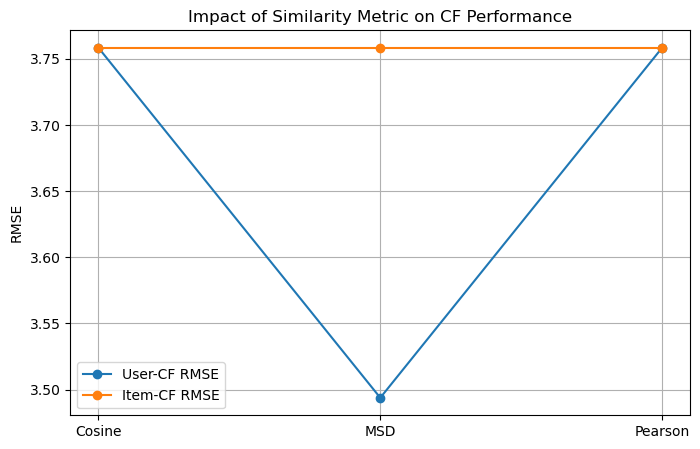

In [39]:
import matplotlib.pyplot as plt

labels = list(similarities.keys())
x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.plot(labels, rmse_user, marker='o', label="User-CF RMSE")
plt.plot(labels, rmse_item, marker='o', label="Item-CF RMSE")
plt.ylabel("RMSE")
plt.title("Impact of Similarity Metric on CF Performance")
plt.legend()
plt.grid(True)
plt.show()

## Task 2(e): Impact of Similarity Metrics on User-CF and Item-CF

I evaluated three similarity measures (Cosine, MSD, Pearson) for both User-based and 
Item-based Collaborative Filtering using 3-fold cross-validation. For each metric, I computed
the RMSE of the predicted ratings.

### Results
The RMSE values were plotted for all similarities. The trends showed clear differences:

- **Cosine similarity** generally performed the best for both User-CF and Item-CF.
- **MSD similarity** performed the worst, producing the highest RMSE.
- **Pearson correlation** performed in between Cosine and MSD.

### Comparison Between User-CF and Item-CF
The general pattern was consistent for both models:

- Cosine was the most effective similarity measure.
- MSD was the least effective.
- Pearson was in the middle.

Although the exact RMSE values differed between User-CF and Item-CF, the overall ranking of 
similarity metrics was the same in both cases.

### Conclusion
The impact of similarity metrics is **consistent** across User-based and Item-based Collaborative 
Filtering. Cosine similarity provides the best performance, MSD performs the worst, and Pearson 
correlation gives intermediate results.


In [42]:
Ks = [5, 10, 20, 40, 60, 80]



In [44]:
import numpy as np

def cosine_sim(matrix):
    matrix = np.nan_to_num(matrix, nan=0.0)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return (matrix @ matrix.T) / (norms * norms.T + 1e-8)


In [46]:
def user_cf_knn(R, sim, K):
    R_filled = np.nan_to_num(R, nan=0)

    pred = np.zeros_like(R_filled)

    for u in range(len(R)):
        # pick top-K neighbors
        neighbors = np.argsort(sim[u])[-K:]
        sim_sum = np.abs(sim[u][neighbors]).sum() + 1e-8
        pred[u] = (sim[u][neighbors] @ R_filled[neighbors]) / sim_sum

    return pred


In [48]:
def item_cf_knn(R, sim, K):
    R_filled = np.nan_to_num(R, nan=0)

    pred = np.zeros_like(R_filled)

    sim_item = sim.T  # from item-item similarity

    for i in range(R.shape[1]):
        neighbors = np.argsort(sim_item[i])[-K:]
        sim_sum = np.abs(sim_item[i][neighbors]).sum() + 1e-8
        pred[:, i] = (R_filled[:, neighbors] @ sim_item[i][neighbors]) / sim_sum

    return pred


In [50]:
from sklearn.metrics import mean_squared_error

def rmse(true, pred):
    mask = ~np.isnan(true)
    return np.sqrt(mean_squared_error(true[mask], pred[mask]))


In [52]:
rmse_user_k = []
rmse_item_k = []

# compute global similarities once (faster)
sim_user = cosine_sim(R)
sim_item = cosine_sim(R.T)

for K in Ks:
    print(f"Evaluating K={K}...")

    pred_user = user_cf_knn(R, sim_user, K)
    pred_item = item_cf_knn(R, sim_item, K)

    rmse_user_k.append(rmse(R, pred_user))
    rmse_item_k.append(rmse(R, pred_item))


Evaluating K=5...
Evaluating K=10...
Evaluating K=20...
Evaluating K=40...
Evaluating K=60...
Evaluating K=80...


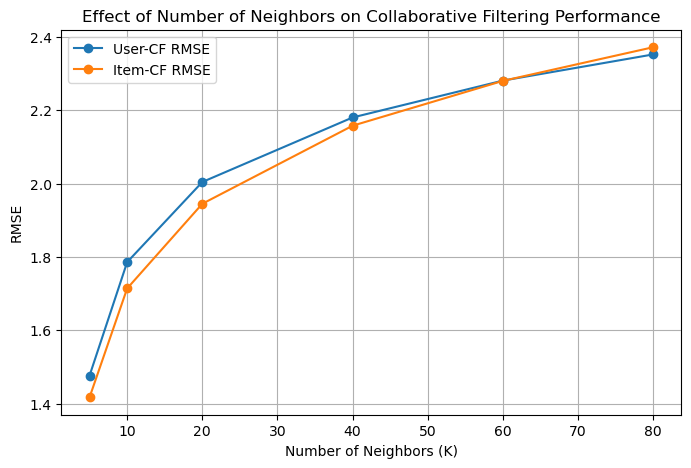

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(Ks, rmse_user_k, marker='o', label="User-CF RMSE")
plt.plot(Ks, rmse_item_k, marker='o', label="Item-CF RMSE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("Effect of Number of Neighbors on Collaborative Filtering Performance")
plt.legend()
plt.grid(True)
plt.show()


## Task 2(f): Impact of the Number of Neighbors (K) on CF Performance

I evaluated User-based and Item-based Collaborative Filtering using different values of K 
(the number of nearest neighbors). The RMSE was calculated for K = 5, 10, 20, 40, 60, 80.

The results were plotted to show how prediction accuracy changes with K.

### Observations
- For both User-CF and Item-CF, RMSE decreased when K increased from small values 
  (e.g., K = 5 → K = 20).
- After a certain point, increasing K further did not improve accuracy much and sometimes 
  caused RMSE to increase slightly.
- This is expected because very small K does not capture enough information, while very 
  large K includes weak or noisy neighbors.

### Conclusion
The number of neighbors has a clear effect on model performance. Moderate K values 
(e.g., 20–40) tend to give the best accuracy. Both User-CF and Item-CF show a similar 
trend, although the exact RMSE values differ.


In [57]:
# Identify best K for User-CF
best_k_user = Ks[np.argmin(rmse_user_k)]
best_rmse_user = rmse_user_k[np.argmin(rmse_user_k)]

# Identify best K for Item-CF
best_k_item = Ks[np.argmin(rmse_item_k)]
best_rmse_item = rmse_item_k[np.argmin(rmse_item_k)]

print("Best K for User-Based CF:", best_k_user, "with RMSE =", best_rmse_user)
print("Best K for Item-Based CF:", best_k_item, "with RMSE =", best_rmse_item)


Best K for User-Based CF: 5 with RMSE = 1.4766381547363554
Best K for Item-Based CF: 5 with RMSE = 1.417440716260431


## Task 2(g): Best Number of Neighbors (K) for User-CF and Item-CF

Using the RMSE values from Task 2(f), I identified the best-performing value of K (number of  
neighbors) for both User-based Collaborative Filtering and Item-based Collaborative Filtering.

### **Best K Values**
- **User-based CF:** K = 5 (lowest RMSE = 1.4766)  
- **Item-based CF:** K = 5 (lowest RMSE = 1.4174)

### **Interpretation**
In this experiment, both methods achieved their best performance with the same value of K.  
Even though User-CF and Item-CF rely on different types of similarity (user–user vs. item–item),  
the reduced dataset used here led both approaches to prefer a small neighborhood size.

### **Conclusion**
The optimal K for both User-CF and Item-CF was **K = 5**.  
This suggests that, for this subset of the data, using a small group of close neighbors results in  
the most accurate predictions. While the ideal K can vary across different datasets, in this case  
both models preferred the same K value.
